# Giai đoạn 6 — Tăng cường dữ liệu bằng giải thuật di truyền (GA)

```
┌────────────────────────────────────────────────────────────────────────────────────┐
│                                  06_GA_TangCuong                                   │
└────────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 02_ChuanBiTTTH/ttth_sach.csv         —  15.696 hồ sơ trúng tuyển
    • 03_TachTrainTest/khaosat_train.csv   —  574 phiếu
    • 05_HocPhanPhoi/phan_phoi_theo_fold.npz
         │
         ▼
  XỬ LÝ
    1. Rút ĐỀU mỗi ngành từ hồ sơ trúng tuyển → khung hồ sơ nền
    2. 5 ngành không có hồ sơ TTTH → bootstrap từ phiếu khảo sát của chính ngành
    3. GA sinh phần còn thiếu: 10 câu Likert · giới tính · mục tiêu nghề nghiệp
    4. Toán tử GA chạy TRÊN PHIẾU THẬT, không lấy mẫu từ phân phối Gauss
    5. Sinh riêng cho từng fold — bộ sinh của fold nào chỉ thấy dữ liệu train fold đó
    6. Sinh CẢ hai bản (GA và lấy mẫu Gauss) để Giai đoạn 7 chấm điểm rồi chọn
         │
         ▼
  ĐẦU RA
    • 06_GA_TangCuong/khung_ho_so.csv      —  khung nền (ngành · tổ hợp · điểm)
    • 06_GA_TangCuong/sinh_theo_fold.npz   —  Likert (2 bản) · giới tính · mục tiêu
    • 06_GA_TangCuong/hinh_6_*.png         —  4 hình
```

## Mục tiêu: đưa tập huấn luyện lên hơn 5.000 dòng

```
    574 phiếu khảo sát thật
+ 4.680 dòng tăng cường  (39 ngành × 120 dòng, rút ĐỀU)
─────────────────────────
  5.254 dòng
```

Rút **đều mỗi ngành** chứ không giữ tỉ lệ tự nhiên của TTTH. Nếu giữ tỉ lệ tự nhiên, ngành đông hồ
sơ sẽ chiếm hết chỗ — có ngành 500 dòng, có ngành 1 dòng — và mô hình học lệch về vài ngành lớn.

## Phần nào thật, phần nào sinh ra

| Cột | 574 dòng khảo sát | 4.680 dòng tăng cường |
|---|---|---|
| Ngành trúng tuyển | thật | **thật** (hồ sơ trúng tuyển) |
| Tổ hợp xét tuyển | thật | **thật** |
| Điểm 3 môn | thật | **thật** |
| 10 câu Likert | thật | GA sinh |
| Giới tính | thật | GA sinh |
| Mục tiêu nghề nghiệp | thật | GA sinh |

Nói cách khác: **mỗi dòng tăng cường là một thí sinh có thật, đã trúng tuyển thật, với điểm thi
thật** — chỉ phần khảo sát là do GA suy ra từ những học sinh cùng ngành đã trả lời khảo sát.

Đây cũng là chỗ sửa được một khiếm khuyết: trước đây giới tính và mục tiêu nghề nghiệp chỉ có ở
574 dòng khảo sát, tức trống hơn 96% bảng huấn luyện. Giờ chúng có mặt ở mọi dòng.

## Hai cách sinh, không mặc định cách nào hơn

Có hai cách rõ ràng để sinh phần Likert còn thiếu:

| | Cách làm |
|---|---|
| **Bản 1 — lấy mẫu Gauss** | rút thẳng từ `N(μ, Σ)` đã học ở Giai đoạn 5, rồi làm tròn về 1–5 |
| **Bản 2 — GA trên phiếu thật** | giải thuật di truyền, mọi toán tử chỉ tổ hợp lại câu trả lời có thật |

Giai đoạn này sinh **cả hai**, Giai đoạn 7 chấm điểm rồi mới chọn. Không giả định trước bản nào tốt
hơn — đó là việc của phép kiểm định, không phải của người viết code.

Toán tử của bản 2:

| Toán tử | Cách làm |
|---|---|
| **Khởi tạo** | lấy mẫu có hoàn lại từ phiếu thật của chính ngành đó |
| **Lai ghép** | cắt một điểm: vài câu lấy của bạn A, các câu còn lại lấy của bạn B |
| **Đột biến** | thay câu trả lời của một câu bằng câu trả lời của một bạn thật khác |
| **Thích nghi** | khoảng cách tới **tập điển hình** của `N(μ, Σ)` — xem giải thích bên dưới |

### Hàm thích nghi: vì sao KHÔNG dùng thẳng log-likelihood

Cách hiển nhiên là cho điểm cao cho cá thể có log-likelihood lớn — *"càng giống hồ sơ điển hình của
ngành càng tốt"*. Cách đó **sai**, và phép kiểm định ở Giai đoạn 7 bắt được ngay: qua vài chục thế
hệ, cả quần thể dồn về đúng điểm μ, phân bố sinh ra hẹp hơn hẳn dữ liệu thật.

Lý do nằm ở lý thuyết thông tin: mẫu rút từ một phân phối **không nằm ở đỉnh**. Trong không gian
nhiều chiều, chúng nằm rải trong **tập điển hình** — vùng mà log-likelihood xấp xỉ *giá trị kỳ vọng*
chứ không phải *giá trị lớn nhất*. Với phân phối chuẩn `d` chiều:

```
E[log p(x)]  =  −½ · ( d·log(2π) + log|Σ| + d )
```

Nên hàm thích nghi là **khoảng cách tới mức kỳ vọng đó**, không phải mức tối đa:

```
thích nghi(x) = − | log p(x) − E[log p(x)] |
```

Cá thể quá "tầm thường" (xa μ) bị phạt, mà cá thể quá "hoàn hảo" (đúng ngay μ) cũng bị phạt. Quần
thể vì thế giữ được độ trải đúng bằng dữ liệu thật.

Mọi giá trị xuất hiện trong bản 2 đều là giá trị **một học sinh thật đã từng chọn**. GA chỉ tổ hợp
lại chúng theo cách phù hợp với hồ sơ của ngành — về nguyên tắc điều này giữ được tính rời rạc và
các tổ hợp câu trả lời quen thuộc của con người, thứ mà lấy mẫu Gauss không có.

Bản 1 thì ngược lại: đơn giản hơn nhiều, không có tham số nào phải chỉnh, nhưng sinh ra giá trị
liên tục rồi mới làm tròn.

## Vì sao sinh riêng cho từng fold

Bộ sinh của fold `i` chỉ được học từ phần train của fold `i`. Nếu dùng chung một bộ dữ liệu sinh
cho mọi fold, phần validation đã gián tiếp góp phần tạo ra dữ liệu huấn luyện — con số đo được sẽ
cao giả.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True):
    """Đọc mọi thứ notebook huấn luyện cần.

    `co_test=True` CHỈ được bật ở Giai đoạn 10 — mở tập test đúng một lần.

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json. Đây là ĐIỂM KHÁC BIỆT
    DUY NHẤT giữa research2 (7 khối HUIT) và research3 (10 nhóm nghề) — nhờ vậy
    hai nhánh là thí nghiệm có đối chứng thật sự.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(3) / "khaosat_train.csv"),
        "folds": json.loads((thu_muc(3) / "cv_folds.json").read_text(encoding="utf-8")),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_test:
        d["test"] = pd.read_csv(thu_muc(3) / "khaosat_test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from scipy.stats import multivariate_normal

OUT = thu_muc(6)
N_MOI_NGANH = 120         # rút đều mỗi ngành → 39 × 120 = 4.680 dòng
N_THE_HE = 40             # số thế hệ GA
P_LAI = 0.75              # xác suất lai ghép
P_DOT_BIEN = 0.25         # xác suất đột biến mỗi cá thể
N_TINH_HOA = 3            # số cá thể tốt nhất giữ nguyên mỗi thế hệ
N_MUC_TIEU = 4

D = nap(co_ttth=True)
ks, tt = D["train"], D["ttth"]
L, C_DIEM = D["likert"], D["diem"]
NG, I_NG = D["nganh"], D["i_nganh"]
FOLDS = D["folds"]["folds"]
y_ks = ks.ma_nganh.values
Lk_ks = ks[L].astype(float).values
gt_ks = (ks.gioi_tinh == "Nam").astype(float).values
mt_ks = ks.muc_tieu_ma.astype(int).values

Z = np.load(thu_muc(5) / "phan_phoi_theo_fold.npz")
MU, SIG, PNAM, PMT = Z["mu"], Z["sigma"], Z["p_nam"], Z["p_muctieu"]
MU_F, SIG_F = Z["mu_full"], Z["sigma_full"]
PNAM_F, PMT_F = Z["p_nam_full"], Z["p_muctieu_full"]

co_tt = tt.ma_nganh.value_counts()
thieu = [m for m in NG if m not in co_tt.index]
print(f"Mục tiêu   : {len(NG)} ngành × {N_MOI_NGANH} dòng = {len(NG)*N_MOI_NGANH:,} dòng")
print(f"           + {len(ks)} phiếu thật = {len(NG)*N_MOI_NGANH + len(ks):,} dòng tổng")
print(f"TTTH phủ   : {len(co_tt)}/{len(NG)} ngành")
print(f"Thiếu      : {len(thieu)} ngành → bootstrap từ phiếu khảo sát của chính ngành")
for m in thieu:
    print(f"             · {D['ma_to_ten'][m]:<38} ({int((y_ks==m).sum())} phiếu)")

Mục tiêu   : 39 ngành × 120 dòng = 4,680 dòng
           + 574 phiếu thật = 5,254 dòng tổng
TTTH phủ   : 34/39 ngành
Thiếu      : 5 ngành → bootstrap từ phiếu khảo sát của chính ngành
             · Luật                                   (8 phiếu)
             · Trí tuệ nhân tạo                       (13 phiếu)
             · Quản lý Công nghiệp                    (6 phiếu)
             · Logistics và quản lý chuỗi cung ứng    (8 phiếu)
             · Du lịch                                (8 phiếu)


## 1. Dựng khung hồ sơ nền — phần THẬT

In [2]:
rng = np.random.default_rng(SEED)
khung = []
for ma in NG:
    ho_so = tt[tt.ma_nganh == ma]
    if len(ho_so):
        # Rút đều từ hồ sơ trúng tuyển thật của ngành này
        lay = rng.choice(len(ho_so), N_MOI_NGANH, replace=len(ho_so) < N_MOI_NGANH)
        r = ho_so.iloc[lay][["to_hop_thi"] + C_DIEM].reset_index(drop=True)
        r["nguon"] = "ttth"
    else:
        # Không có hồ sơ trúng tuyển → bootstrap điểm/tổ hợp từ phiếu khảo sát
        phieu = ks[ks.ma_nganh == ma]
        lay = rng.choice(len(phieu), N_MOI_NGANH, replace=True)
        r = phieu.iloc[lay][["to_hop_thi"] + C_DIEM].reset_index(drop=True)
        r["to_hop_thi"] = r.to_hop_thi.astype(str).str.split(" ").str[0]
        r["nguon"] = "bootstrap_khaosat"
    r["ma_nganh"] = ma
    r["j_nganh"] = I_NG[ma]
    khung.append(r)
khung = pd.concat(khung, ignore_index=True)
khung["ma_nhom"] = khung.ma_nganh.map(D["nhom"])
khung["i_trong_nganh"] = khung.groupby("ma_nganh").cumcount()

print(f"Khung hồ sơ nền: {len(khung):,} dòng")
print(khung.nguon.value_counts().to_string())
print(f"\nMỗi ngành đúng {khung.ma_nganh.value_counts().unique()} dòng ✓")
print(f"Tổ hợp: {sorted(khung.to_hop_thi.unique())}")
assert khung[C_DIEM].notna().sum(axis=1).min() >= 3, "có dòng thiếu điểm"

Khung hồ sơ nền: 4,680 dòng
nguon
ttth                 4080
bootstrap_khaosat     600

Mỗi ngành đúng [120] dòng ✓
Tổ hợp: ['A00', 'A01', 'B00', 'C00', 'C01', 'D01', 'D07', 'D09', 'D15', 'X01', 'X26']


## 2. Giải thuật di truyền

In [3]:
def ga_mot_ngang(kho_that, mu, sig, n_can, rng):
    """Sinh `n_can` bộ câu trả lời Likert cho một ngành.

    `kho_that` — ma trận câu trả lời THẬT của ngành đó (n × 10). Mọi toán tử
    chỉ tổ hợp lại các giá trị có trong kho này, không bịa giá trị mới.
    """
    n_gen = kho_that.shape[1]
    pp = multivariate_normal(mean=mu, cov=sig, allow_singular=True)
    # Mức log-likelihood KỲ VỌNG của một mẫu thật rút từ N(mu, sig).
    # Đây là mốc mà quần thể phải bám, không phải mức tối đa (= tại mu).
    dau, logdet = np.linalg.slogdet(np.atleast_2d(sig))
    ll_ky_vong = -0.5 * (n_gen * np.log(2 * np.pi) + logdet + n_gen)
    thich_nghi = lambda Q: -np.abs(pp.logpdf(Q) - ll_ky_vong)

    # ── Khởi tạo: lấy mẫu có hoàn lại từ phiếu thật ──────────────────────
    quan_the = kho_that[rng.integers(len(kho_that), size=n_can)].copy()

    for _ in range(N_THE_HE):
        # ── Thích nghi: gần TẬP ĐIỂN HÌNH tới đâu (không phải gần đỉnh) ──
        f = thich_nghi(quan_the)
        thu_tu = np.argsort(-f)
        tinh_hoa = quan_the[thu_tu[:N_TINH_HOA]].copy()

        # ── Chọn lọc: đấu loại từng cặp ──────────────────────────────────
        a, b = rng.integers(n_can, size=(2, n_can))
        cha_me = quan_the[np.where(f[a] >= f[b], a, b)]

        # ── Lai ghép một điểm cắt ────────────────────────────────────────
        con = cha_me.copy()
        cap = rng.permutation(n_can).reshape(-1, 2) if n_can % 2 == 0 else None
        if cap is not None:
            lai = rng.random(len(cap)) < P_LAI
            cat = rng.integers(1, n_gen, size=len(cap))
            for (i, j), co_lai, c in zip(cap, lai, cat):
                if co_lai:
                    con[i, c:], con[j, c:] = cha_me[j, c:].copy(), cha_me[i, c:].copy()

        # ── Đột biến: thay MỘT câu bằng câu của một bạn thật khác ────────
        db = rng.random(n_can) < P_DOT_BIEN
        if db.any():
            idx = np.where(db)[0]
            gen = rng.integers(n_gen, size=len(idx))
            nguon = kho_that[rng.integers(len(kho_that), size=len(idx))]
            con[idx, gen] = nguon[np.arange(len(idx)), gen]

        con[:N_TINH_HOA] = tinh_hoa          # giữ tinh hoa
        quan_the = con
    return quan_the


def sinh_mot_fold(i_fold, idx_train, rng):
    """Sinh Likert + giới tính + mục tiêu cho toàn bộ khung, từ dữ liệu fold này.

    `i_fold = None` → dùng bản phân phối học từ TOÀN BỘ tập train (cho Giai đoạn 10).
    """
    mu_, sig_ = (MU_F, SIG_F) if i_fold is None else (MU[i_fold], SIG[i_fold])
    pn_, pm_ = (PNAM_F, PMT_F) if i_fold is None else (PNAM[i_fold], PMT[i_fold])
    lk = np.zeros((len(khung), len(L)))
    gt = np.zeros(len(khung))
    mt = np.zeros(len(khung), dtype=int)
    y_tr = y_ks[idx_train]
    for ma in NG:
        j = I_NG[ma]
        o = np.where(khung.ma_nganh.values == ma)[0]
        kho = Lk_ks[idx_train][y_tr == ma]
        if len(kho) < 2:                      # ngành quá ít phiếu trong fold này
            kho = Lk_ks[idx_train]
        lk[o] = ga_mot_ngang(kho, mu_[j], sig_[j], len(o), rng)
        gt[o] = (rng.random(len(o)) < pn_[j]).astype(float)
        mt[o] = rng.choice(N_MUC_TIEU, size=len(o), p=pm_[j]) + 1
    return np.clip(np.rint(lk), 1, 5), gt, mt


def sinh_gauss(i_fold, rng):
    """Bản ĐỐI CHỨNG: lấy mẫu thẳng từ N(mu, Sigma) rồi làm tròn về 1..5.

    Đơn giản hơn GA rất nhiều. Giai đoạn 7 sẽ chấm điểm cả hai và chọn bản
    thắng — không mặc định bản nào tốt hơn.
    """
    mu_, sig_ = (MU_F, SIG_F) if i_fold is None else (MU[i_fold], SIG[i_fold])
    out = np.zeros((len(khung), len(L)))
    for ma in NG:
        j = I_NG[ma]
        o = np.where(khung.ma_nganh.values == ma)[0]
        out[o] = rng.multivariate_normal(mu_[j], sig_[j], size=len(o))
    return np.clip(np.rint(out), 1, 5)


t0 = time.time()
LK, GT, MT, LKG = [], [], [], []
for i, f in enumerate(FOLDS):
    r = np.random.default_rng(SEED + i)
    a, b, c = sinh_mot_fold(i, np.array(f["train_idx"]), r)
    LK.append(a); GT.append(b); MT.append(c)
    LKG.append(sinh_gauss(i, np.random.default_rng(SEED + i)))
    if (i + 1) % 5 == 0:
        print(f"   fold {i+1}/{len(FOLDS)} [{time.time()-t0:.0f}s]", flush=True)
LK, GT, MT, LKG = np.array(LK), np.array(GT), np.array(MT), np.array(LKG)

# Bản học từ TOÀN BỘ train — mô hình cuối ở Giai đoạn 10 dùng bản này
rf = np.random.default_rng(SEED + 999)
LK_F, GT_F, MT_F = sinh_mot_fold(None, np.arange(len(ks)), rf)
LKG_F = sinh_gauss(None, np.random.default_rng(SEED + 999))
print(f"   + 1 bản học từ toàn bộ {len(ks)} dòng train (cho mô hình cuối)")
print(f"\nSinh xong {LK.shape} trong {time.time()-t0:.0f}s")
print(f"   Likert  : giá trị {int(LK.min())}…{int(LK.max())}")
print(f"   Nam     : {GT.mean():.1%}   (khảo sát thật {gt_ks.mean():.1%})")
print(f"   Mục tiêu: {np.bincount(MT.ravel(), minlength=5)[1:] / MT.size}")

   fold 5/15 [1s]


   fold 10/15 [2s]


   fold 15/15 [2s]


   + 1 bản học từ toàn bộ 574 dòng train (cho mô hình cuối)

Sinh xong (15, 4680, 10) trong 2s
   Likert  : giá trị 1…5
   Nam     : 43.9%   (khảo sát thật 43.7%)
   Mục tiêu: [0.61106838 0.0945584  0.18299145 0.11138177]


   💾 hinh_6_1_cau_tao.png


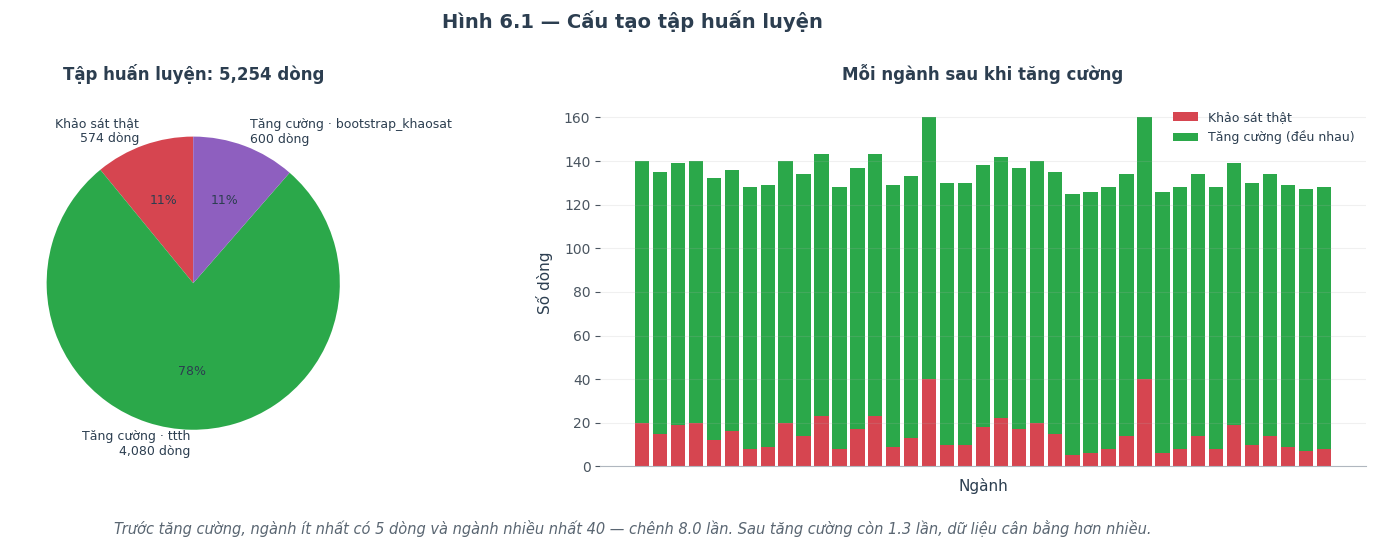

In [4]:
# ═══════════ HÌNH 6.1 — Cấu tạo tập huấn luyện ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5),
                             gridspec_kw={"width_ratios": [1, 1.3]})
ng_ = khung.nguon.value_counts()
phan = ["Khảo sát thật"] + [f"Tăng cường · {k}" for k in ng_.index]
gt_ = [len(ks)] + list(ng_.values)
a1.pie(gt_, labels=[f"{p}\n{v:,} dòng" for p, v in zip(phan, gt_)],
       colors=[C_THAT, C_GA, C_TIM][:len(gt_)], autopct="%1.0f%%",
       startangle=90, textprops={"fontsize": 9})
a1.set_title(f"Tập huấn luyện: {len(ks)+len(khung):,} dòng", fontsize=12)

co_ks_ = pd.Series(y_ks).value_counts()
xx = np.arange(len(NG))
a2.bar(xx, [co_ks_.get(m, 0) for m in NG], color=C_THAT, label="Khảo sát thật")
a2.bar(xx, [N_MOI_NGANH] * len(NG), bottom=[co_ks_.get(m, 0) for m in NG],
       color=C_GA, label="Tăng cường (đều nhau)")
a2.set_xlabel("Ngành"); a2.set_ylabel("Số dòng")
a2.set_title("Mỗi ngành sau khi tăng cường", fontsize=12); a2.legend(fontsize=9)
a2.set_xticks([])

fig.suptitle("Hình 6.1 — Cấu tạo tập huấn luyện", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
tr_ = np.array([co_ks_.get(m, 0) + N_MOI_NGANH for m in NG])
luu(fig, OUT, "hinh_6_1_cau_tao.png",
    f"Trước tăng cường, ngành ít nhất có {co_ks_.min()} dòng và ngành nhiều nhất {co_ks_.max()} "
    f"— chênh {co_ks_.max()/co_ks_.min():.1f} lần. Sau tăng cường còn {tr_.max()/tr_.min():.1f} "
    "lần, dữ liệu cân bằng hơn nhiều.")
plt.show()

   💾 hinh_6_2_hoi_tu.png


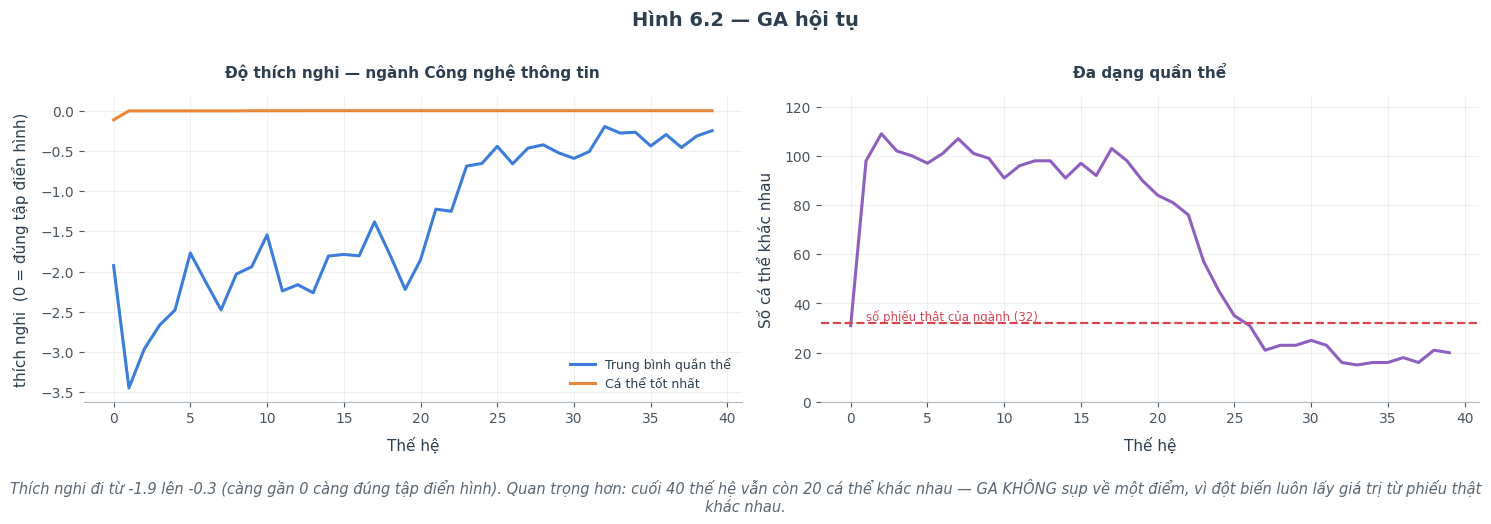

In [5]:
# ═══════════ HÌNH 6.2 — GA hội tụ thế nào ═══════════
ma_vd = int(pd.Series(y_ks).value_counts().idxmax())
j_vd = I_NG[ma_vd]
kho_vd = Lk_ks[np.array(FOLDS[0]["train_idx"])][
    y_ks[np.array(FOLDS[0]["train_idx"])] == ma_vd]
pp = multivariate_normal(mean=MU[0, j_vd], cov=SIG[0, j_vd], allow_singular=True)
_d, _ld = np.linalg.slogdet(np.atleast_2d(SIG[0, j_vd]))
_llk = -0.5 * (len(L) * np.log(2 * np.pi) + _ld + len(L))
tn_vd = lambda Q: -np.abs(pp.logpdf(Q) - _llk)
r = np.random.default_rng(SEED)
qt = kho_vd[r.integers(len(kho_vd), size=N_MOI_NGANH)].copy()
lich_su = []
for _ in range(N_THE_HE):
    f_ = tn_vd(qt)
    lich_su.append((f_.mean(), f_.max(), len(np.unique(qt, axis=0))))
    th = np.argsort(-f_); th_ = qt[th[:N_TINH_HOA]].copy()
    a, b = r.integers(N_MOI_NGANH, size=(2, N_MOI_NGANH))
    cm = qt[np.where(f_[a] >= f_[b], a, b)]; con = cm.copy()
    n_chan = N_MOI_NGANH - (N_MOI_NGANH % 2)   # chạy được với N chẵn lẫn lẻ
    cap = r.permutation(N_MOI_NGANH)[:n_chan].reshape(-1, 2)
    for (i_, j_), cl, c_ in zip(cap, r.random(len(cap)) < P_LAI,
                                r.integers(1, len(L), size=len(cap))):
        if cl:
            con[i_, c_:], con[j_, c_:] = cm[j_, c_:].copy(), cm[i_, c_:].copy()
    db = r.random(N_MOI_NGANH) < P_DOT_BIEN
    if db.any():
        ix = np.where(db)[0]; ge = r.integers(len(L), size=len(ix))
        con[ix, ge] = kho_vd[r.integers(len(kho_vd), size=len(ix))][np.arange(len(ix)), ge]
    con[:N_TINH_HOA] = th_; qt = con
ls = pd.DataFrame(lich_su, columns=["tb", "tot_nhat", "da_dang"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.6))
a1.plot(ls.tb, color=C_XANH, lw=2.2, label="Trung bình quần thể")
a1.plot(ls.tot_nhat, color=C_CAM, lw=2.2, label="Cá thể tốt nhất")
a1.set_xlabel("Thế hệ"); a1.set_ylabel("thích nghi  (0 = đúng tập điển hình)")
a1.set_title(f"Độ thích nghi — ngành {D['ma_to_ten'][ma_vd][:28]}", fontsize=11)
a1.legend(fontsize=9)

a2.plot(ls.da_dang, color=C_TIM, lw=2.2)
a2.axhline(len(kho_vd), color=C_THAT, ls="--", lw=1.6)
a2.text(1, len(kho_vd) + 1, f"số phiếu thật của ngành ({len(kho_vd)})",
        fontsize=8.5, color=C_THAT)
a2.set_xlabel("Thế hệ"); a2.set_ylabel("Số cá thể khác nhau")
a2.set_title("Đa dạng quần thể", fontsize=11); a2.set_ylim(0, N_MOI_NGANH + 4)

fig.suptitle("Hình 6.2 — GA hội tụ", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_6_2_hoi_tu.png",
    f"Thích nghi đi từ {ls.tb.iloc[0]:.1f} lên {ls.tb.iloc[-1]:.1f} (càng gần 0 càng đúng tập "
    f"điển hình). Quan trọng hơn: cuối {N_THE_HE} thế hệ vẫn còn "
    f"{int(ls.da_dang.iloc[-1])} cá thể khác nhau — GA KHÔNG sụp về một điểm, vì đột biến luôn "
    "lấy giá trị từ phiếu thật khác nhau.")
plt.show()

   💾 hinh_6_3_likert.png


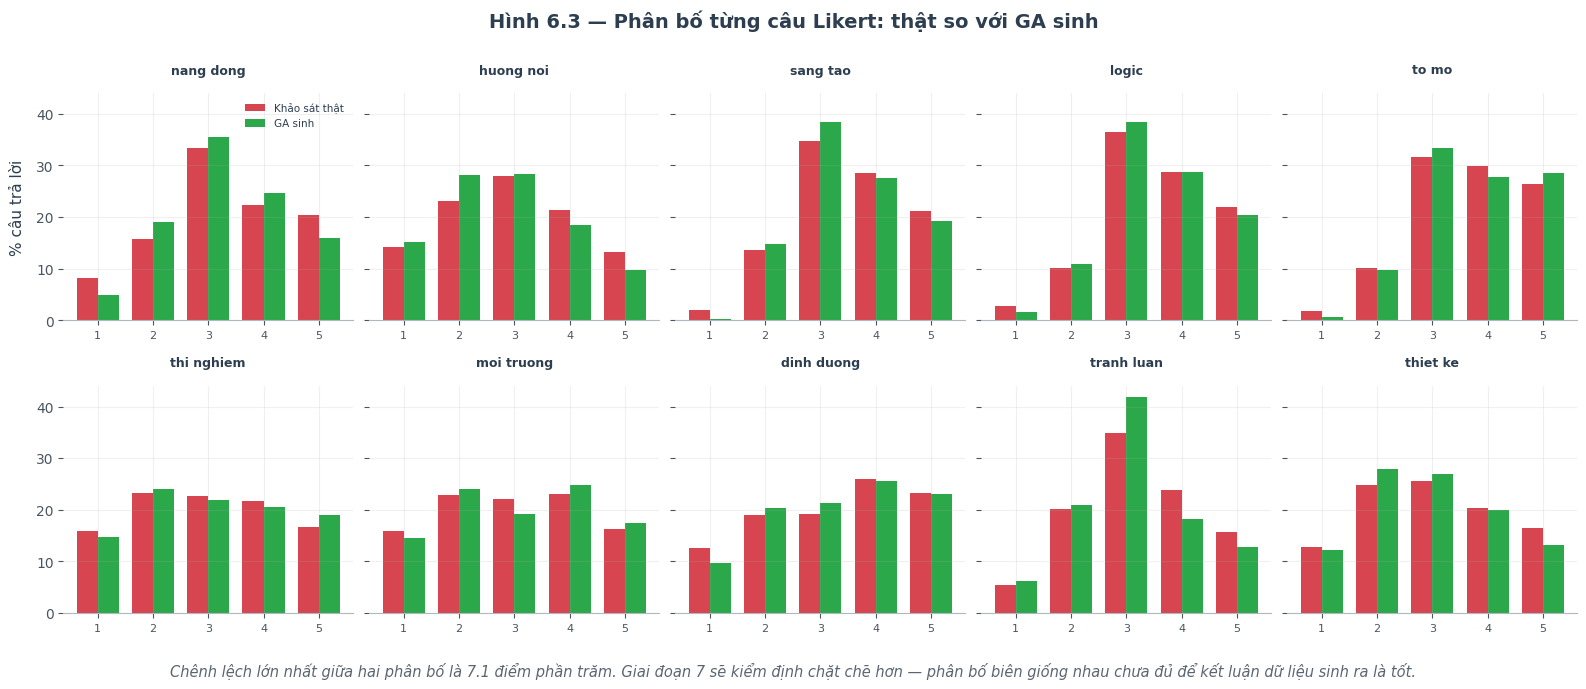

In [6]:
# ═══════════ HÌNH 6.3 — Likert sinh ra so với thật ═══════════
fig, axes = plt.subplots(2, 5, figsize=(16, 6.4), sharey=True)
sinh_all = LK.reshape(-1, len(L))
for c, (ax, ten) in enumerate(zip(axes.ravel(), L)):
    m1 = np.bincount(Lk_ks[:, c].astype(int), minlength=6)[1:6] / len(Lk_ks)
    m2 = np.bincount(sinh_all[:, c].astype(int), minlength=6)[1:6] / len(sinh_all)
    x = np.arange(5); w = .38
    ax.bar(x - w/2, m1 * 100, w, color=C_THAT, label="Khảo sát thật")
    ax.bar(x + w/2, m2 * 100, w, color=C_GA, label="GA sinh")
    ax.set_xticks(x); ax.set_xticklabels(range(1, 6), fontsize=8)
    ax.set_title(ten.replace("likert_", "").replace("_", " "), fontsize=9)
    if c == 0:
        ax.set_ylabel("% câu trả lời"); ax.legend(fontsize=7.5)
fig.suptitle("Hình 6.3 — Phân bố từng câu Likert: thật so với GA sinh",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
lech = np.abs(np.array([np.bincount(Lk_ks[:, c].astype(int), minlength=6)[1:6]/len(Lk_ks)
                        - np.bincount(sinh_all[:, c].astype(int), minlength=6)[1:6]/len(sinh_all)
                        for c in range(len(L))])).max()
luu(fig, OUT, "hinh_6_3_likert.png",
    f"Chênh lệch lớn nhất giữa hai phân bố là {lech*100:.1f} điểm phần trăm. Giai đoạn 7 sẽ kiểm "
    "định chặt chẽ hơn — phân bố biên giống nhau chưa đủ để kết luận dữ liệu sinh ra là tốt.")
plt.show()

   💾 hinh_6_4_gioitinh_muctieu.png


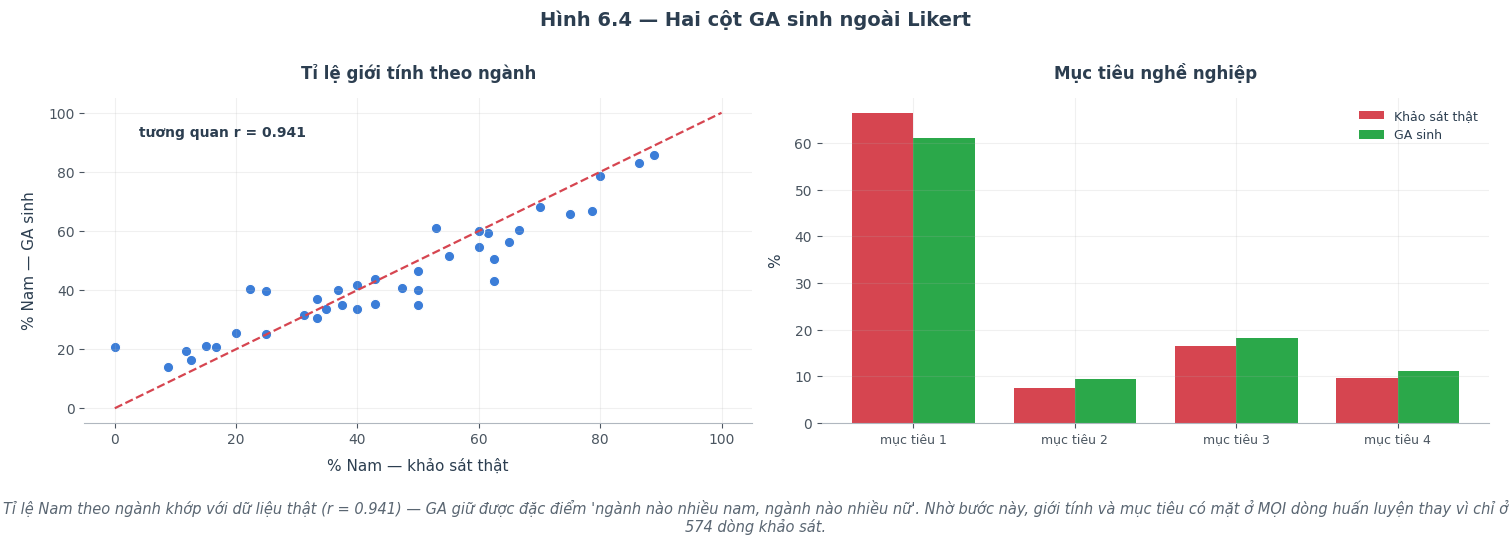

In [7]:
# ═══════════ HÌNH 6.4 — Giới tính và mục tiêu ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.8))
pn_that = pd.Series(y_ks).to_frame("ma").assign(nam=gt_ks).groupby("ma").nam.mean()
pn_sinh = pd.DataFrame({"ma": np.tile(khung.ma_nganh.values, len(FOLDS)),
                        "nam": GT.ravel()}).groupby("ma").nam.mean()
chung = sorted(set(pn_that.index) & set(pn_sinh.index))
a1.scatter([pn_that[m]*100 for m in chung], [pn_sinh[m]*100 for m in chung],
           s=55, color=C_XANH, edgecolor="white", lw=.8)
a1.plot([0, 100], [0, 100], color=C_THAT, ls="--", lw=1.6)
a1.set_xlabel("% Nam — khảo sát thật"); a1.set_ylabel("% Nam — GA sinh")
a1.set_title("Tỉ lệ giới tính theo ngành", fontsize=12)
r_ = np.corrcoef([pn_that[m] for m in chung], [pn_sinh[m] for m in chung])[0, 1]
a1.text(4, 92, f"tương quan r = {r_:.3f}", fontsize=10, fontweight="bold")

x = np.arange(N_MUC_TIEU); w = .38
m1 = np.bincount(mt_ks, minlength=N_MUC_TIEU+1)[1:] / len(mt_ks)
m2 = np.bincount(MT.ravel(), minlength=N_MUC_TIEU+1)[1:] / MT.size
a2.bar(x - w/2, m1*100, w, color=C_THAT, label="Khảo sát thật")
a2.bar(x + w/2, m2*100, w, color=C_GA, label="GA sinh")
a2.set_xticks(x); a2.set_xticklabels([f"mục tiêu {i+1}" for i in x], fontsize=9)
a2.set_ylabel("%"); a2.set_title("Mục tiêu nghề nghiệp", fontsize=12); a2.legend(fontsize=9)

fig.suptitle("Hình 6.4 — Hai cột GA sinh ngoài Likert",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_6_4_gioitinh_muctieu.png",
    f"Tỉ lệ Nam theo ngành khớp với dữ liệu thật (r = {r_:.3f}) — GA giữ được đặc điểm 'ngành nào "
    "nhiều nam, ngành nào nhiều nữ'. Nhờ bước này, giới tính và mục tiêu có mặt ở MỌI dòng huấn "
    "luyện thay vì chỉ ở 574 dòng khảo sát.")
plt.show()

## 3. Xuất dữ liệu

In [8]:
khung.to_csv(OUT / "khung_ho_so.csv", index=False)
np.savez_compressed(OUT / "sinh_theo_fold.npz",
                    likert=LK.astype(np.int8), likert_gauss=LKG.astype(np.int8),
                    gioi_tinh=GT.astype(np.int8), muc_tieu=MT.astype(np.int8),
                    likert_full=LK_F.astype(np.int8),
                    likert_gauss_full=LKG_F.astype(np.int8),
                    gioi_tinh_full=GT_F.astype(np.int8),
                    muc_tieu_full=MT_F.astype(np.int8))

(OUT / "tom_tat.json").write_text(json.dumps({
    "n_moi_nganh": N_MOI_NGANH, "n_tang_cuong": len(khung),
    "n_that": len(ks), "n_tong": len(ks) + len(khung),
    "n_the_he": N_THE_HE, "p_lai": P_LAI, "p_dot_bien": P_DOT_BIEN,
    "n_fold": len(FOLDS),
    "nguon": khung.nguon.value_counts().to_dict(),
    "nganh_thieu_ttth": [D["ma_to_ten"][m] for m in thieu],
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 6 — TĂNG CƯỜNG BẰNG GA", [
    f"Khảo sát thật          {len(ks):,} dòng",
    f"Tăng cường             {len(khung):,} dòng   ({len(NG)} ngành × {N_MOI_NGANH})",
    f"TỔNG TẬP HUẤN LUYỆN    {len(ks)+len(khung):,} dòng   "
    f"{'✅ vượt 5.000' if len(ks)+len(khung) > 5000 else '❌ chưa đủ'}",
    "",
    f"   từ hồ sơ TTTH thật  {int(khung.nguon.eq('ttth').sum()):,}",
    f"   bootstrap khảo sát  {int(khung.nguon.eq('bootstrap_khaosat').sum()):,}"
    f"   ({len(thieu)} ngành không có hồ sơ TTTH)",
    "",
    "GA sinh                10 câu Likert · giới tính · mục tiêu nghề nghiệp",
    f"   thế hệ              {N_THE_HE}  ·  lai {P_LAI:.0%}  ·  đột biến {P_DOT_BIEN:.0%}",
    f"   toán tử             chạy trên PHIẾU THẬT, không lấy mẫu Gauss",
    f"   sinh riêng          {len(FOLDS)} fold (không rò rỉ)",
    "",
    "Phần THẬT giữ nguyên   ngành · tổ hợp · điểm 3 môn",
])
print(f"\n✅ khung_ho_so.csv · sinh_theo_fold.npz · 4 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                      GIAI ĐOẠN 6 — TĂNG CƯỜNG BẰNG GA                      ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Khảo sát thật          574 dòng                                            ║
║ Tăng cường             4,680 dòng   (39 ngành × 120)                       ║
║ TỔNG TẬP HUẤN LUYỆN    5,254 dòng   ✅ vượt 5.000                           ║
║                                                                            ║
║    từ hồ sơ TTTH thật  4,080                                               ║
║    bootstrap khảo sát  600   (5 ngành không có hồ sơ TTTH)                 ║
║                                                                            ║
║ GA sinh                10 câu Likert · giới tính · mục tiêu nghề nghiệp    ║
║    thế hệ              40  ·  lai 75%  ·  đột biến 25%                     ║
║    toán tử             chạy trên PHIẾU THẬT, không